## Library check

In [ ]:
import numpy as np
import os
import torch
import torchaudio
import logger

#log = logger.Log("output/logs")

print("Torch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

if torch.cuda.is_available():
    print("CUDA available")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA unavailable")


Torch version: 2.5.1
Torchaudio version: 2.5.1
CUDA available
GPU count: 1
GPU device: NVIDIA GeForce GTX 1050


## Load Dataset

Feature batch shape: torch.Size([16, 1, 513, 1217])
Labels batch shape: torch.Size([16, 3])


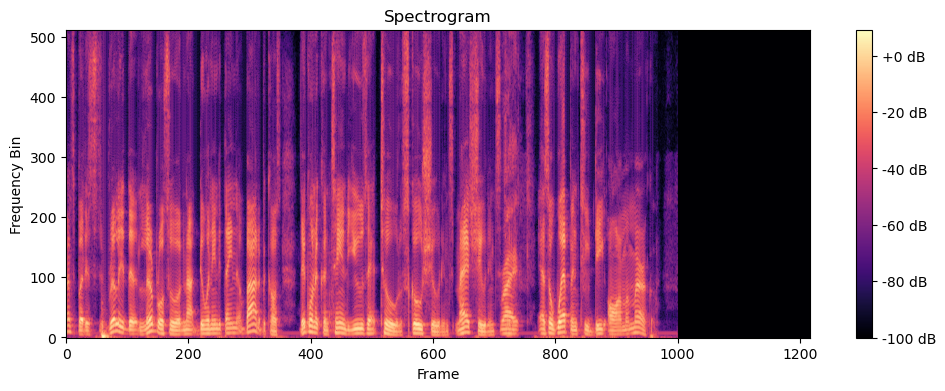

Label: tensor([2.6000, 4.6000, 5.0000])
Normalized Label:  tensor([-0.4667,  0.2000,  0.3333])


In [ ]:
import audiotools
import torch
import torchaudio
from torch.utils.data import DataLoader

#Dataset parameters:
hparameters = {
    "batch_size": 16,
    "shuffle": True,
    "collate_function": audiotools.Batching.spectrogram_dynamic,
    "target_transform": audiotools.TSFMnormalizeM1(1, 7)
    }

#Spectogram parameters
spectogram_transform = torchaudio.transforms.Spectrogram(
    n_fft=1024,
    hop_length=160,
    win_length=400,
    window_fn=torch.hamming_window,
    normalized=True
    )

#Train partition
msp_vad_train = audiotools.AudioDatasetVAD(
    r"C:\Datasets\_compiled\msp-podcast-2\labels_train_VAD.csv", 
    r"C:\Datasets\_compiled\msp-podcast-2\Train",
    transform=spectogram_transform,
    target_transform=hparameters["target_transform"]
    )
train_dataloader = DataLoader(
    msp_vad_train,
    batch_size=hparameters["batch_size"],
    shuffle=hparameters["shuffle"],
    collate_fn=hparameters["collate_function"]
    )

#Development(validation) partition
msp_vad_dev = audiotools.AudioDatasetVAD(
    r"C:\Datasets\_compiled\msp-podcast-2\labels_development_VAD.csv",
    r"C:\Datasets\_compiled\msp-podcast-2\Development",
    transform=spectogram_transform,
    target_transform=hparameters["target_transform"]
    )
dev_dataloader = DataLoader(
    msp_vad_dev,
    batch_size=hparameters["batch_size"],
    shuffle=hparameters["shuffle"],
    collate_fn=hparameters["collate_function"]
    )

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

waveform = train_features[0]
label = train_labels[0]
audiotools.Plot.spectrogram(waveform, ylabel="Frequency Bin", xlabel="Frame")
print(f"Label: {label}")

normalize_transform = audiotools.TSFMnormalizeM1(1, 7)
print("Normalized Label: ", normalize_transform(label))